# Enron Email Analysis E2E

Loads `emails_preprocessed_no_spam.csv` and collapses each `thread_id` into one document (the same join as `topic-model-hpo --join-threads`). One row is one thread. `From`, `To`, and `Date` are the earliest message in that thread.

1. EDA
2. Linguistic feature extraction
3. Topic modeling
4. Entities and sentiment analysis
5. Network analysis
6. Time-series analysis
7. Classification

In [45]:
import pandas as pd

from email_cls_with_clustering.topics import join_by_thread

messages = pd.read_csv("emails_preprocessed_no_spam.csv")
messages.info()

/tmp/ipykernel_1800392/3447740451.py:5: DtypeWarning: Columns (14: X-bcc, 18: Time, 19: Attendees) have mixed types. Specify dtype option on import or set low_memory=False.
  messages = pd.read_csv("emails_preprocessed_no_spam.csv")


<class 'pandas.DataFrame'>
RangeIndex: 180706 entries, 0 to 180705
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   file                       180706 non-null  str    
 1   Message-ID                 180706 non-null  str    
 2   Date                       180706 non-null  str    
 3   From                       180706 non-null  str    
 4   To                         174747 non-null  str    
 5   Cc                         52578 non-null   str    
 6   Bcc                        52578 non-null   str    
 7   Subject                    175282 non-null  str    
 8   Mime-Version               180682 non-null  float64
 9   Content-Type               180682 non-null  str    
 10  Content-Transfer-Encoding  180682 non-null  str    
 11  X-From                     180682 non-null  str    
 12  X-To                       177280 non-null  str    
 13  X-cc                       53054 non-nul

In [46]:
df = join_by_thread(messages)
print(f"{len(messages)} messages -> {len(df)} threads")
df.info()

180706 messages -> 144085 threads
<class 'pandas.DataFrame'>
RangeIndex: 144085 entries, 0 to 144084
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   thread_id    144085 non-null  int64              
 1   n_messages   144085 non-null  int64              
 2   embed_text   144085 non-null  str                
 3   ctfidf_text  144085 non-null  str                
 4   subj_norm    134948 non-null  str                
 5   date_parsed  144085 non-null  datetime64[us, UTC]
 6   From         144085 non-null  str                
 7   To           138453 non-null  str                
 8   Subject      138661 non-null  str                
 9   Date         144085 non-null  str                
dtypes: datetime64[us, UTC](1), int64(2), str(7)
memory usage: 312.1 MB


## EDA

This analysis should envelop:

- Weekly volume overtime
- Length distribution
- Top senders/receivers
- Domain stopword review

### Data preview

In [47]:
# first, get a sneak peek of the dataframe
df.head()

,thread_id,n_messages,embed_text,ctfidf_text,subj_norm,date_parsed,From,To,Subject,Date
0,1,1,EOL report for TV in conference on 33\n\nCash\...,eol report for tv in conference on 33 cash heh...,NaN,1980-01-01 00:00:00+00:00,phillip.allen@enron.com,"stephen.harrington@enron.com, mary@enron.com",NaN,"Mon, 31 Dec 1979 16:00:00 -0800"
1,2,1,"Re: MISSION SOUTH Jeff,\n\n I want to bid $2.8...",re mission south jeff i want to bid 28 for sag...,mission south,1980-01-01 00:00:00+00:00,phillip.allen@enron.com,jsmith@austintx.com,Re: MISSION SOUTH,"Mon, 31 Dec 1979 16:00:00 -0800"
2,3,1,systems wish list attached is the systems wish...,systems wish list attached is the systems wish...,systems wish list,1980-01-01 00:00:00+00:00,phillip.allen@enron.com,"john.lavorato@enron.com, beth.perlman@enron.co...",systems wish list,"Mon, 31 Dec 1979 16:00:00 -0800"
3,4,1,"Re: <PERSON>,\n\n It is OK to buy a carpet sha...",re person it is ok to buy a carpet shampooer a...,NaN,1980-01-01 00:00:00+00:00,phillip.allen@enron.com,maryrichards7@hotmail.com,Re:,"Mon, 31 Dec 1979 16:00:00 -0800"
4,5,1,"<PERSON>,\n\nIn response to your ideas\n\nTime...",person in response to your ideas time and cost...,NaN,1980-01-01 00:00:00+00:00,phillip.allen@enron.com,c@enron.com,NaN,"Mon, 31 Dec 1979 16:00:00 -0800"


### Weekly volume over time

In [48]:
# Thread date is the earliest message. Epoch zeros and future typos stay out of time plots.
df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
dated = df.loc[
    df["Date"].between(
        pd.Timestamp("1999-01-01", tz="UTC"),
        pd.Timestamp("2002-12-31 23:59:59", tz="UTC"),
    )
].copy()
print(f"{len(dated)} threads dated 1999-2002 ({len(df) - len(dated)} excluded)")

143679 threads dated 1999-2002 (406 excluded)


In [49]:
df["Date"].value_counts()

Date
2001-06-27 23:02:00+00:00    382
2001-06-26 22:32:00+00:00    289
1980-01-01 00:00:00+00:00    241
2001-02-22 01:26:00+00:00     51
2001-07-26 22:44:00+00:00     40
                            ... 
2004-02-04 02:14:30+00:00      1
2007-02-11 21:32:50+00:00      1
2043-12-28 19:34:12+00:00      1
2044-01-02 23:46:00+00:00      1
2044-01-04 22:48:58+00:00      1
Name: count, Length: 133491, dtype: int64

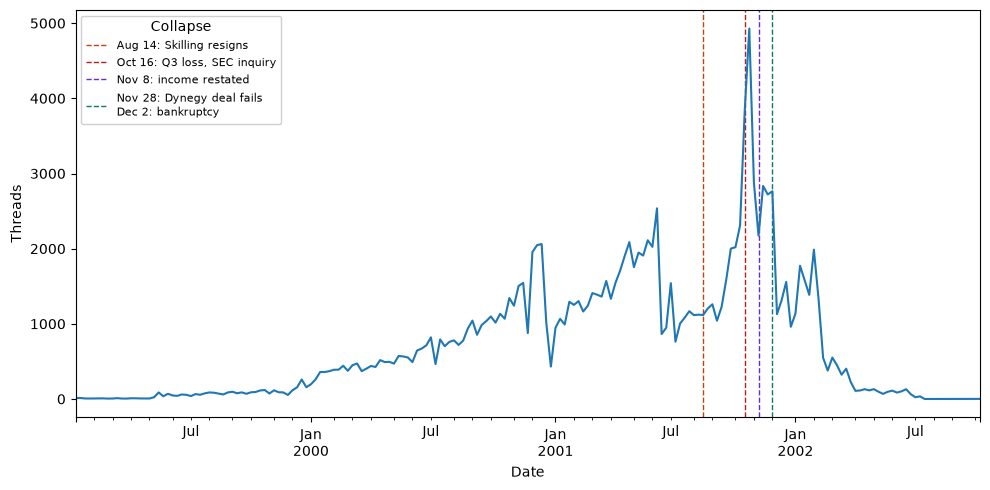

In [50]:
# weekly count of threads (by earliest message)
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Public dates for the second-half-2001 collapse.
COLLAPSE_EVENTS = [
    (pd.Timestamp("2001-08-14"), "Aug 14: Skilling resigns"),
    (pd.Timestamp("2001-10-16"), "Oct 16: Q3 loss, SEC inquiry"),
    (pd.Timestamp("2001-11-08"), "Nov 8: income restated"),
    (pd.Timestamp("2001-11-28"), "Nov 28: Dynegy deal fails"),
    (pd.Timestamp("2001-12-02"), "Dec 2: bankruptcy"),
]
_COLLAPSE_COLORS = ["#c2410c", "#b91c1c", "#6d28d9", "#0f766e", "#111827"]


def mark_collapse(ax=None, loc="upper left", bbox_to_anchor=None, legend=True):
    """Dashed lines for the 2001 collapse. Leaves any existing legend in place."""
    ax = ax or plt.gca()
    freq = getattr(ax.xaxis, "freq", None)
    lo, hi = ax.get_xlim()
    placed = {}
    for (when, label), color in zip(COLLAPSE_EVENTS, _COLLAPSE_COLORS):
        if freq is not None:
            x = float(pd.Period(when, freq=freq).ordinal)
        else:
            x = float(mdates.date2num(when.to_pydatetime()))
        if x < lo or x > hi:
            continue
        bucket = placed.setdefault(x, {"color": color, "labels": []})
        bucket["labels"].append(label)
    handles = [
        ax.axvline(
            x,
            color=bucket["color"],
            ls="--",
            lw=1,
            label="\n".join(bucket["labels"]),
            zorder=1,
        )
        for x, bucket in placed.items()
    ]
    if not handles or not legend:
        return handles
    existing = ax.get_legend()
    legend_artist = ax.legend(
        handles=handles,
        loc=loc,
        bbox_to_anchor=bbox_to_anchor,
        fontsize=8,
        framealpha=0.92,
        title="Collapse",
    )
    if existing is not None:
        ax.add_artist(existing)
    return legend_artist


weekly = dated.set_index("Date").resample("W").size()
plt.figure(figsize=(10, 5))
weekly.plot()
plt.xlabel("Date")
plt.ylabel("Threads")
mark_collapse()
plt.tight_layout()
plt.show()

Emails peakeed around end of 2001. Hold steadyish between beg. 2000 and first quarter of 2002.

### Length distribution

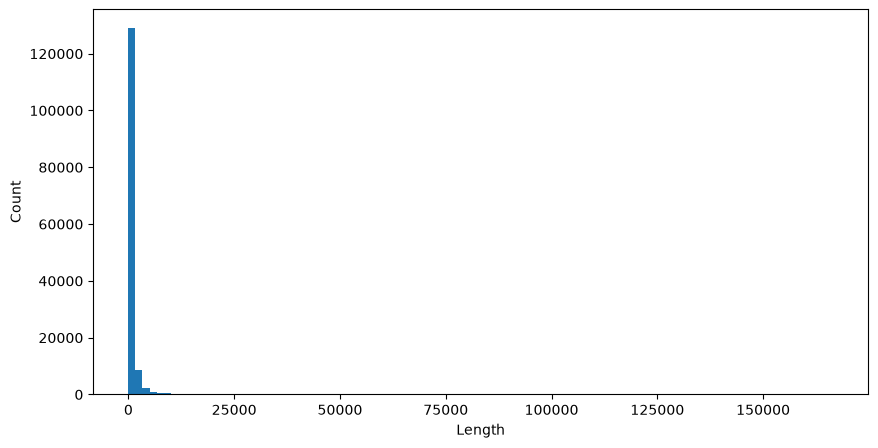

In [7]:
# distribution of thread length (joined embed_text)
plt.figure(figsize=(10, 5))
plt.hist(df["embed_text"].str.len(), bins=100)
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

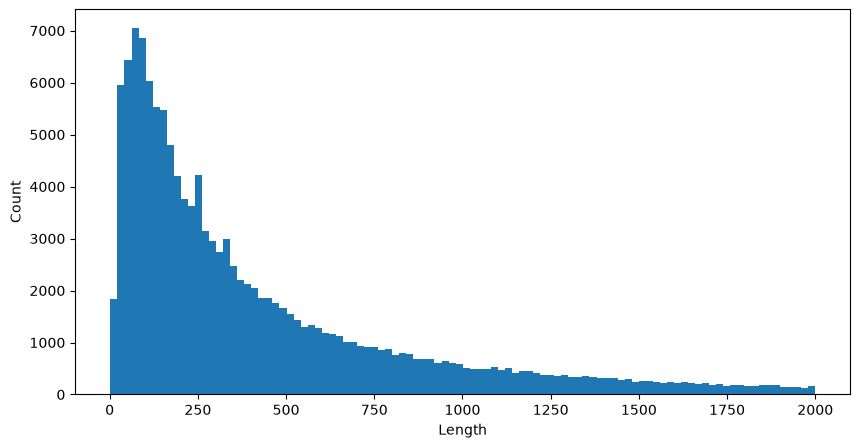

In [8]:
# distribution of email length < 2000 characters
plt.figure(figsize=(10, 5))
plt.hist(df[df["embed_text"].str.len() < 2000]["embed_text"].str.len(), bins=100)
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

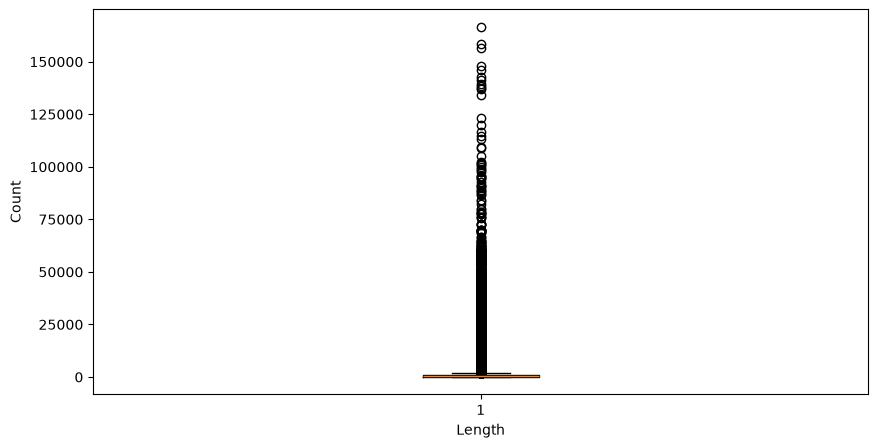

In [9]:
# boxplot to see iqr and outliers
plt.figure(figsize=(10, 5))
plt.boxplot(df["embed_text"].str.len())
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

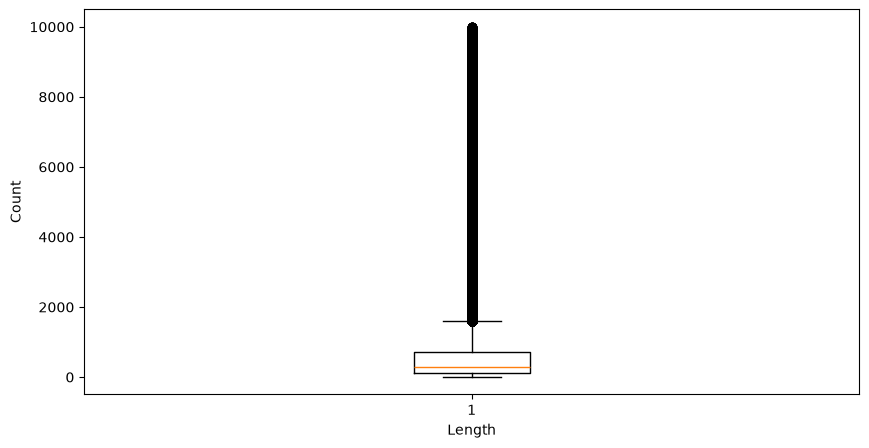

In [10]:
# boxplot to see iqr and outliers
plt.figure(figsize=(10, 5))
plt.boxplot(df[df["embed_text"].str.len() < 10000]["embed_text"].str.len())
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [11]:
# Tukey fence: above Q3 + 1.5 * IQR
lengths = df["embed_text"].str.len()
q1 = lengths.quantile(0.25)
q3 = lengths.quantile(0.75)
iqr = q3 - q1
fence = q3 + 1.5 * iqr
print(f"IQR: {iqr:.0f}  fence: {fence:.0f}")
outliers = df[lengths > fence]
print(f"Outliers: {len(outliers)}")
outliers.head()

IQR: 617  fence: 1670
Outliers: 14948


,thread_id,n_messages,embed_text,ctfidf_text,subj_norm,date_parsed,From,To,Subject,Date
6,7,1,RE: technical help for interviewing traders In...,re technical help for interviewing traders in ...,technical help for interviewing traders,1980-01-01 00:00:00+00:00,john.arnold@enron.com,tom.wilbeck@enron.com,RE: technical help for interviewing traders,1980-01-01 00:00:00+00:00
10,12,1,<LOCATION> fixed income <LOCATION>\n\nI quickl...,location fixed income location i quickly plott...,us fixed income,1980-01-01 00:00:00+00:00,harry.arora@enron.com,pushkar.shahi@enron.com,US fixed income,1980-01-01 00:00:00+00:00
47,62,2,"""Chinese Wall"" Classroom Training Chinese Wall...",chinese wall classroom training chinese wall t...,"""chinese wall"" classroom training",1980-01-01 00:00:00+00:00,janette.elbertson@enron.com,"steve.jacobellis@enron.com, pushkar.shahi@enro...","""Chinese Wall"" Classroom Training",1980-01-01 00:00:00+00:00
89,107,1,Spotlight Report\n Exchange products seeing sl...,spotlight report exchange products seeing slow...,NaN,1980-01-01 00:00:00+00:00,vince.kaminski@enron.com,vince.kaminski@enron.com,NaN,1980-01-01 00:00:00+00:00
96,114,1,Re: Job Titles and Job Banding Thanks for your...,re job titles and job banding thanks for your ...,job titles and job banding,1980-01-01 00:00:00+00:00,steven.kean@enron.com,wade.cline@enron.com,Re: Job Titles and Job Banding,1980-01-01 00:00:00+00:00


### Top senders and receivers

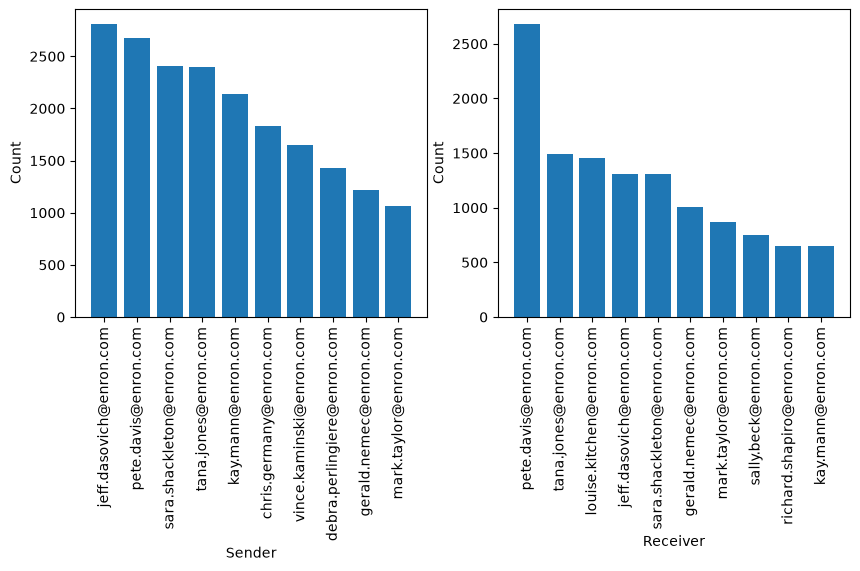

In [12]:
# From/To are the first message in the thread
senders = df["From"].value_counts()
receivers = df["To"].value_counts()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 2 subplots: top 10 senders and top 10 receivers
ax[0].bar(senders.index[:10], senders.values[:10])
ax[0].set_xlabel("Sender")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=90)
ax[1].bar(receivers.index[:10], receivers.values[:10])
ax[1].set_xlabel("Receiver")
ax[1].set_ylabel("Count")
ax[1].tick_params(axis='x', rotation=90)
plt.show()


Let's see if pete davis was receiving real stuff or a bunch of spam...

In [13]:
df[df["To"] == "pete.davis@enron.com"]['From'].value_counts()

From
pete.davis@enron.com          2675
chris.stokley@enron.com          2
phillip.platter@enron.com        2
bill.iii@enron.com               1
kourtney.nelson@enron.com        1
jim.reyes@enron.com              1
kate.symes@enron.com             1
monika.causholli@enron.com       1
Name: count, dtype: int64

In [14]:
# sum of these where cc is not null
# df[(df["To"] == "pete.davis@enron.com") & (df["From"] == "pete.davis@enron.com")]['Cc'] 

It seems that Pete Davis had a unique way of sending emails... he would send them all to himself and CC everyone else.. wtf

### Domain stopword review

In [15]:
# Tokens match the HPO CountVectorizer: letters only, same stop list, no lemma or POS filter.
import re

from email_cls_with_clustering.topics import TOKEN_PATTERN, default_stop_words

STOP = set(default_stop_words())
TOKEN = re.compile(TOKEN_PATTERN)

def to_tokens(text):
    if not isinstance(text, str):
        return []
    return [tok for tok in TOKEN.findall(text) if tok not in STOP]

texts = df["ctfidf_text"].tolist()


/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.13) or chardet (7.6.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


In [16]:
from tqdm import tqdm

df["tokens"] = [to_tokens(text) for text in tqdm(texts)]


100%|██████████| 144085/144085 [00:04<00:00, 31173.42it/s]


In [17]:
from collections import Counter
dfreq = Counter(w for toks in df.tokens for w in set(toks))

print([w for w, c in dfreq.most_common(60)])  # filler still here belongs in configs/.../email_stop_words


['questions', 'meeting', 'gas', 'energy', 'power', 'work', 'following', 'going', 'agreement', 'dont', 'forward', 'deal', 'persons', 'market', 'review', 'business', 'im', 'report', 'company', 'office', 'available', 'find', 'price', 'received', 'trading', 'sent', 'comments', 'working', 'file', 'schedule', 'changes', 'final', 'credit', 'system', 'way', 'morning', 'set', 'process', 'contract', 'services', 'said', 'conference', 'plan', 'end', 'ill', 'current', 'days', 'best', 'tomorrow', 'right', 'order', 'service', 'draft', 'soon', 'free', 'people', 'possible', 'team', 'phone', 'address']


In [18]:
dfreq

Counter({'questions': 15505,
         'meeting': 15411,
         'gas': 13655,
         'energy': 12050,
         'power': 11746,
         'work': 11548,
         'following': 11508,
         'going': 11076,
         'agreement': 10482,
         'dont': 10356,
         'forward': 9990,
         'deal': 9881,
         'persons': 9862,
         'market': 9814,
         'review': 9805,
         'business': 9802,
         'im': 9131,
         'report': 8867,
         'company': 8846,
         'office': 8665,
         'available': 8436,
         'find': 8257,
         'price': 8203,
         'received': 8055,
         'trading': 7948,
         'sent': 7902,
         'comments': 7780,
         'working': 7628,
         'file': 7615,
         'schedule': 7542,
         'changes': 7419,
         'final': 7161,
         'credit': 7073,
         'system': 7000,
         'way': 6984,
         'morning': 6969,
         'set': 6888,
         'process': 6799,
         'contract': 6747,
         'ser

## 

In [19]:
# get top 20 tokens with counts
dfreq.most_common(40)

[('questions', 15505),
 ('meeting', 15411),
 ('gas', 13655),
 ('energy', 12050),
 ('power', 11746),
 ('work', 11548),
 ('following', 11508),
 ('going', 11076),
 ('agreement', 10482),
 ('dont', 10356),
 ('forward', 9990),
 ('deal', 9881),
 ('persons', 9862),
 ('market', 9814),
 ('review', 9805),
 ('business', 9802),
 ('im', 9131),
 ('report', 8867),
 ('company', 8846),
 ('office', 8665),
 ('available', 8436),
 ('find', 8257),
 ('price', 8203),
 ('received', 8055),
 ('trading', 7948),
 ('sent', 7902),
 ('comments', 7780),
 ('working', 7628),
 ('file', 7615),
 ('schedule', 7542),
 ('changes', 7419),
 ('final', 7161),
 ('credit', 7073),
 ('system', 7000),
 ('way', 6984),
 ('morning', 6969),
 ('set', 6888),
 ('process', 6799),
 ('contract', 6747),
 ('services', 6745)]

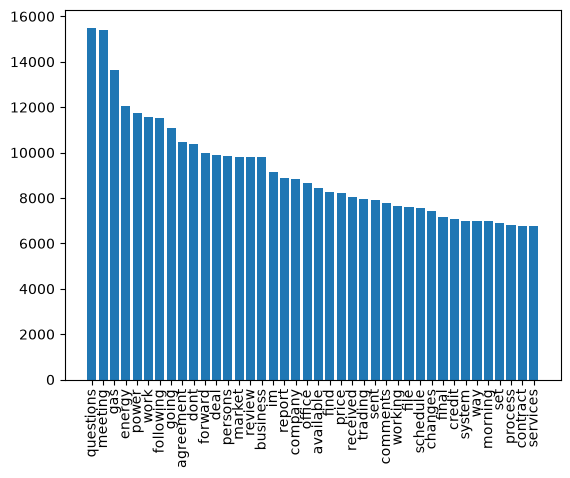

In [20]:
plt.bar([x[0] for x in dfreq.most_common(40)], [x[1] for x in dfreq.most_common(40)])
plt.xticks(rotation=90)
plt.show()

## Linguistic Feature Extraction

This section encapsualates token and phrase analysis, TF-IDF, and log-odds analysis overtime

In [21]:
# Phrases ranked by score. BERTopic itself uses CountVectorizer ngrams (1, 2), not this gensim model.
from gensim.models.phrases import Phrases, ENGLISH_CONNECTOR_WORDS

bigram = Phrases(df["tokens"], min_count=20, threshold=10, connector_words=ENGLISH_CONNECTOR_WORDS)
trigram = Phrases(bigram[df["tokens"]], min_count=10, threshold=10)
df["tokens_ph"] = [trigram[bigram[t]] for t in df["tokens"]]

scored = sorted(trigram.export_phrases().items(), key=lambda kv: kv[1], reverse=True)
print(scored[:40])


[('engy_purchsale', 918123045.0), ('speicota_coiled', 98530278.0), ('omnicalendarentry_omnicalendarentry', 78376357.5), ('initialize_borland', 78003136.75), ('gadsden_research_services_fercwatch', 73897708.5), ('outbox_synchronizing', 70165501.0), ('codesite_hourahead', 56462967.75), ('fromlocationid_schedtype_engy_purchsale', 48145476.75), ('epmicisoblue_engytype', 43293607.0), ('synchronizing_folder_notes_synchronizing', 38317330.333333336), ('synchronizing_folder_drafts_synchronizing', 37322075.0), ('synchronizing_folder_journal_synchronizing', 36326819.666666664), ('synchronizing_folder_tasks_synchronizing', 30355287.666666668), ('damons_doormats', 29671049.625), ('pgae_pntofintrc_schedtype_engy', 29111218.5), ('codesite_hourahead_hour_ancillary', 28594451.307692308), ('notre_dame', 24632569.5), ('synchronizing_folder_outbox_synchronizing', 23388500.333333332), ('inocoms_endofday', 21049650.3), ('bobette_riner', 19034258.25), ('synchronizing_folder_contacts_synchronizing', 18909851

In [22]:
# Bag-of-words and TF-IDF for phrases
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
docs = df.tokens_ph.str.join(" ")

tfidf = TfidfVectorizer(min_df=5, max_df=0.5, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(docs)
vocab = tfidf.get_feature_names_out()
row = tfidf_matrix[0].toarray().ravel()
ranked = sorted(((score, term) for score, term in zip(row, vocab) if score > 0), reverse=True)
print(ranked[:20])


[(np.float64(0.402208432391935), 'hehub'), (np.float64(0.36806087868827303), 'waha'), (np.float64(0.3576009209309735), 'pepl'), (np.float64(0.34057525873945654), 'prompt_month'), (np.float64(0.33286918382391895), 'katy'), (np.float64(0.29200103151983803), 'chicago'), (np.float64(0.2681889276134598), 'tv'), (np.float64(0.23364964899252041), 'nymex'), (np.float64(0.20414733589798095), 'eol'), (np.float64(0.20169686039063267), 'cash'), (np.float64(0.16977668682641547), 'conference'), (np.float64(0.1585049022063275), 'report')]


In [23]:
# log odd dirichlet analysis
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
def log_odds_dirichlet(docs_a, docs_b, prior_scale=0.01, min_df=5):
    cv = CountVectorizer(min_df=min_df); cv.fit(list(docs_a) + list(docs_b))
    ya = np.asarray(cv.transform(docs_a).sum(0)).ravel()
    yb = np.asarray(cv.transform(docs_b).sum(0)).ravel()
    alpha = (ya + yb) * prior_scale + 1e-3
    na, nb, a0 = ya.sum(), yb.sum(), alpha.sum()
    delta = (np.log((ya + alpha) / (na + a0 - ya - alpha))
    - np.log((yb + alpha) / (nb + a0 - yb - alpha)))
    var = 1 / (ya + alpha) + 1 / (yb + alpha)
    z = delta / np.sqrt(var)

    return pd.Series(z, index=cv.get_feature_names_out()).sort_values()
cut = pd.Timestamp("2001-08-01", tz="UTC")
in_window = df.index.isin(dated.index)
pre = docs[in_window & (df.Date < cut)]
post = docs[in_window & (df.Date >= cut)]
z = log_odds_dirichlet(post, pre)
print("Distinctive AFTER Aug-2001:", z.tail(20).index.tolist())
print("Distinctive BEFORE:", z.head(20).index.tolist())


Distinctive AFTER Aug-2001: ['company', 'estate', 'cash', 'reuters', 'merger', 'news', 'collapse', 'investors', 'executives', 'employees', 'shares', 'file_oportlandwestdeskcalifornia_schedulingiso_final', 'companys', 'dynegy', 'ubs', 'partnerships', 'updated', 'synchronizing_folder', 'stock', 'enrons']
Distinctive BEFORE: ['state', 'power', 'agreement', 'summer', 'utilities', 'generators', 'electricity', 'ena', 'draft', 'comments', 'pge', 'legal', 'governor', 'language', 'ventures', 'iso', 'counterparty', 'isda', 'states', 'hpl']


## Topic Modeling

Run LDA, NMF and BERTopic models. Evaluate each.

In [24]:
# save tokenized df
df.to_csv("emails_with_tokens.csv", index = False)

### LDA

In [25]:
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel

dictionary = Dictionary(df.tokens_ph)
dictionary.filter_extremes(no_below=10, no_above=0.4, keep_n=20000)
corpus = [dictionary.doc2bow(t) for t in df.tokens_ph]
results = []
for k in [10, 15, 20, 30, 40]:
    lda = LdaMulticore(
        corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        iterations=200,
        alpha="asymmetric",
        eta="auto",
        chunksize=2000,
        random_state=42,
        workers=3,
    )
    cv = CoherenceModel(
        model=lda, texts=df.tokens_ph, dictionary=dictionary, coherence="c_v"
    ).get_coherence()
    npmi = CoherenceModel(
        model=lda, texts=df.tokens_ph, dictionary=dictionary, coherence="c_npmi"
    ).get_coherence()
    um = CoherenceModel(
        model=lda, corpus=corpus, dictionary=dictionary, coherence="u_mass"
    ).get_coherence()
    results.append((k, cv, npmi, um))
    print(k, round(cv, 3), round(npmi, 3), round(um, 3))

best = max(results, key=lambda row: row[2])
print("best k by c_npmi:", best[0], "npmi", round(best[2], 3))


10 0.489 0.034 -3.041
15 0.528 0.061 -2.125
20 0.507 0.054 -2.146
30 0.503 0.05 -2.387
40 0.483 0.029 -2.709
best k by c_npmi: 15 npmi 0.061


In [26]:
from sklearn.decomposition import NMF

def top_words(H, vocab, n=10):
    return [[vocab[i] for i in row.argsort()[::-1][:n]] for row in H]

nmf = NMF(
    n_components=20,
    init="nndsvda",
    beta_loss="kullback-leibler",
    solver="mu",
    max_iter=400,
    random_state=42,
)
W = nmf.fit_transform(tfidf_matrix)
for i, ws in enumerate(top_words(nmf.components_, vocab)):
    print(f"NMF {i}: {' '.join(ws)}")


NMF 0: market business said costs potential years power million cost believe
NMF 1: file_oportlandwestdeskcalifornia_schedulingiso_final ancillary_schedules_awarded_variances hourahead_hour_hourahead_hour detected_log_messages_parsing schedulestxt wind schedule_matches_final_individual interchange_schedule_unable_assign restructuring_sue_mara mws_word
NMF 2: meeting tomorrow attend set calendar meetings afternoon room mtg scheduled
NMF 3: hour_ancillary_schedules_awarded hourahead_hour_codesite_hourahead parsing_file_oportlandwestdeskcalifornia_schedulingiso variances_detected_log_messages final_schedulestxt continuing final_schedulestxt_error_retrieving hourahead_price_data_process variances_detected_variances_detected mkttype_transdate_tiepoint_interchgid
NMF 4: going im ill weekend dont work great night guys got
NMF 5: file sent received print files read respond fax sending case
NMF 6: deal deals numbers book pl price changed ees correct month
NMF 7: review agreement draft comments 

### BERTopic — Stage 5 finalist validation

Topic analusis, outlier reduction, LLM labels, hierarchy to
~10 themes, word-intrusion check on the top 20 topics.

In [1]:
from bertopic import BERTopic

model = BERTopic.load("emails_clustered_BAAI_bge-small-en-v1.5__mean_removal__umap_nc50_nn100__mcs200_ms50_eom_eps0.0__unreduced_20261001T023137_model.pkl")

/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.13) or chardet (7.6.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


In [2]:
model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86614,-1_gas_energy_agreement_meeting,"[gas, energy, agreement, meeting, power, quest...",[trs state newswire 2500 am edition telecommun...
1,0,7529,0_said_company_enrons_dow jones,"[said, company, enrons, dow jones, dow, jones,...",[enron mentions enron q2 eps 45 cents beats es...
2,1,4772,1_power_energy_state_said,"[power, energy, state, said, electricity, util...",[energy central direct daily edition monday ja...
3,2,4373,2_gas_capacity_pipeline_meter,"[gas, capacity, pipeline, meter, deal, mmbtud,...",[tco capacity update effective for october 10 ...
4,3,3038,3_meeting_staff meeting_central canada_attend,"[meeting, staff meeting, central canada, atten...","[request a meeting, meeting next week, meeting..."
...,...,...,...,...,...
71,70,210,70_website trv_trv notification_trv_viewing we...,"[website trv, trv notification, trv, viewing w...",[trv notification ng price pl 12052001 the rep...
72,71,206,71_payment_invoice_check_paid,"[payment, invoice, check, paid, account, invoi...",[expenses i have never received any expense in...
73,72,203,72_dell_order_drive_computer,"[dell, order, drive, computer, monitor, pc, la...",[dell order confirmation dear person thank you...
74,73,203,73_database_alias_error_unknown database,"[database, alias, error, unknown database, dat...",[schedule crawler hourahead failure start date...


In [3]:
model.visualize_topics()

They're actually scattered! This is great!

In [4]:
import pandas as pd

df = pd.read_csv("emails_with_tokens.csv")

In [5]:
docs_phrases = df.tokens_ph
docs = df.tokens
hierarchical_topics = model.hierarchical_topics(docs)
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 74/74 [00:04<00:00, 17.56it/s]


### Topic Reduction

Let's merge some topics. a lot are too small to be useful.

In [6]:
from typing import Iterable

topics_to_merge: list[Iterable[int] | int] = [
 [37, 47, 58, 65, 74, 21],  # time (?)
 [51, 4, 16, 55, 50, 48],  # legal issues
 [24, 33, 12],  # general electric agreement
 [66, 10, 26],  # fantasy football
 [38, 19, 6, 34, 5, 8, 15, 68, 54, 30, 14, 23, 41],  # miscelaneous office talk
 [61, 28, 0, 1, 2, 69],  # stock talk
 [36, 29, 3, 11],  # meetings
 [9],  # ?
 [39],  # ?
 [44, 53, 64],  # enronline power credit reports
 [31],  # financial books
 [13, 7, 17],  # financial curves, imbalances, etc.
 [71],  # payments/invoices
 [43],  # budget allocation planning
 [62, 63],  # file archive
 [59],  # requests to print
 [42],  # presentations
 [18],  # job promotions
 [52, 25, 20],  # myiso, californiaiso, market talk
 [35, 72, 22, 56, 45],  # IT emails
 [27],  # esmtp?
 [40],  # confidential
 [73],  # database alias error ?
 [49, 57, 32],  # power credit trade
 [46, 67],  # expenses reporting
 [60],  # erv position report?
 [70],  # website trv notification
]

# merge_topics mutates in place and returns None
model.merge_topics(docs=docs, topics_to_merge=topics_to_merge)
model.visualize_topics()


In [ ]:
# Load (or compute) BAAI embeddings used for the topic model.
from pathlib import Path

import numpy as np
from sentence_transformers import SentenceTransformer

from email_cls_with_clustering.embeddings import load_or_embed, embedding_cache_path

docs_text = df["embed_text"].fillna("").astype(str).tolist()
emb_cache = embedding_cache_path(
    Path("."),
    backend="sentence_transformer",
    model="BAAI/bge-small-en-v1.5",
)
embeddings = load_or_embed(
    docs_text,
    emb_cache,
    backend="sentence_transformer",
    model="BAAI/bge-small-en-v1.5",
    batch_size=128,
)
print(emb_cache, embeddings.shape)

# Keep a live ST model only for KeyBERT / visualize helpers below.
embeddings_model = SentenceTransformer("BAAI/bge-small-en-v1.5")
model.visualize_documents(docs_text, embeddings=embeddings)


In [8]:
import os
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI as OpenAIClient
from bertopic.backend._utils import select_backend
from bertopic.representation import OpenAI, KeyBERTInspired

load_dotenv(Path(".env"))  # notebooks/.env when cwd is notebooks/

# Loaded BERTopic pickles drop the embedding backend; KeyBERT needs it.
model.embedding_model = select_backend(embeddings_model)

prompt = """I have a topic from corporate emails described by these keywords:
[KEYWORDS]
Representative emails:
[DOCUMENTS]
Return a short business label (max 6 words) for this topic. Label:"""

client = OpenAIClient(api_key=os.environ["OPENAI_API_KEY"])
llm_rep = OpenAI(
    client,
    model="gpt-4o",
    prompt=prompt,
    nr_docs=4,
    diversity=0.1,
    doc_length=200,
    tokenizer="whitespace",
)
model.update_topics(
    docs_text,
    representation_model={"LLM": llm_rep, "KeyBERT": KeyBERTInspired()},
)



In [9]:
model.get_topic_info()[["Topic", "Count", "LLM"]]

,Topic,Count,LLM
0,-1,86614,[Energy and Finance Industry News]
1,0,17638,[Enron and Energy Market Issues]
2,1,9822,[Personal and Professional Correspondence]
3,2,5062,[Meeting and Conference Scheduling]
4,3,3853,[ISDA Master Agreements and Negotiations]
5,4,3057,[Risk Management and Curve Analysis]
6,5,2107,[California Energy Scheduling Variance Reports]
7,6,2095,[Turbine Sale and Agreement Drafting]
8,7,1921,[Scheduled Network and System Outages]
9,8,1852,[Fantasy Football Updates and Promotions]


In [11]:
# Pickle can't serialize SentenceTransformer / OpenAI HTTP clients (RLock).
# Detach those backends, save the fitted topic state, then restore for the session.
from pathlib import Path

import numpy as np

from email_cls_with_clustering.embeddings import texts_fingerprint
from email_cls_with_clustering.topics import save_topic_model

emb_path = Path("embeddings_sentence_transformer_BAAI_bge-small-en-v1.5.npy")
np.save(emb_path, np.asarray(embeddings, dtype=np.float32))
emb_path.with_suffix(".fingerprint").write_text(texts_fingerprint(docs_text))
print(f"saved embeddings → {emb_path} shape={np.asarray(embeddings).shape}")

model_path = Path("optimal_enron_topic_model_merged.pkl")
_embedding_backend = model.embedding_model
_representation = model.representation_model
model.embedding_model = None
model.representation_model = None
try:
    save_topic_model(model, model_path)
    print(f"saved topic model → {model_path}")
finally:
    model.embedding_model = _embedding_backend
    model.representation_model = _representation

# LLM/KeyBERT labels live in topic_representations_ / get_topic_info();
# re-attach backends after load if you need update_topics again:
#   model.embedding_model = select_backend(SentenceTransformer("BAAI/bge-small-en-v1.5"))


2026-10-02 08:09:01,869 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


saved embeddings → embeddings_sentence_transformer_BAAI_bge-small-en-v1.5.npy shape=(144085, 384)
saved topic model → optimal_enron_topic_model_merged.pkl


### Sentiment Analysis per-topic

Per-topic and per-topic over time

In [51]:
from bertopic import BERTopic
import pandas as pd

model = BERTopic.load("optimal_enron_topic_model_merged.pkl")
df = pd.read_csv("emails_with_tokens.csv")


In [52]:
from nltk.sentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
df["vader"] = df["embed_text"].map(lambda t: vader.polarity_scores(t)["compound"])

In [53]:
df[['vader','embed_text']].head()

,vader,embed_text
0,0.0000,EOL report for TV in conference on 33\n\nCash\...
1,0.0772,"Re: MISSION SOUTH Jeff,\n\n I want to bid $2.8..."
2,0.6597,systems wish list attached is the systems wish...
3,0.4466,"Re: <PERSON>,\n\n It is OK to buy a carpet sha..."
4,-0.3400,"<PERSON>,\n\nIn response to your ideas\n\nTime..."


In [54]:
topic_info = model.get_topic_info()[["Topic", "LLM"]].rename(
    columns={"Topic": "topic", "LLM": "topic_name"}
)
topic_info["topic_name"] = topic_info["topic_name"].map(
    lambda x: x[0] if isinstance(x, (list, tuple)) else x
)

assert len(model.topics_) == len(df)
df["topic"] = model.topics_
df = df.merge(topic_info, on="topic", how="left")

In [55]:
# add topic column to df so we have topic information in there

df.to_csv("emails_with_sentiment_tokens_topics.csv", index = False)

#### Compare VADER sentiment between topics

Text(0.5, 0, 'Topic')

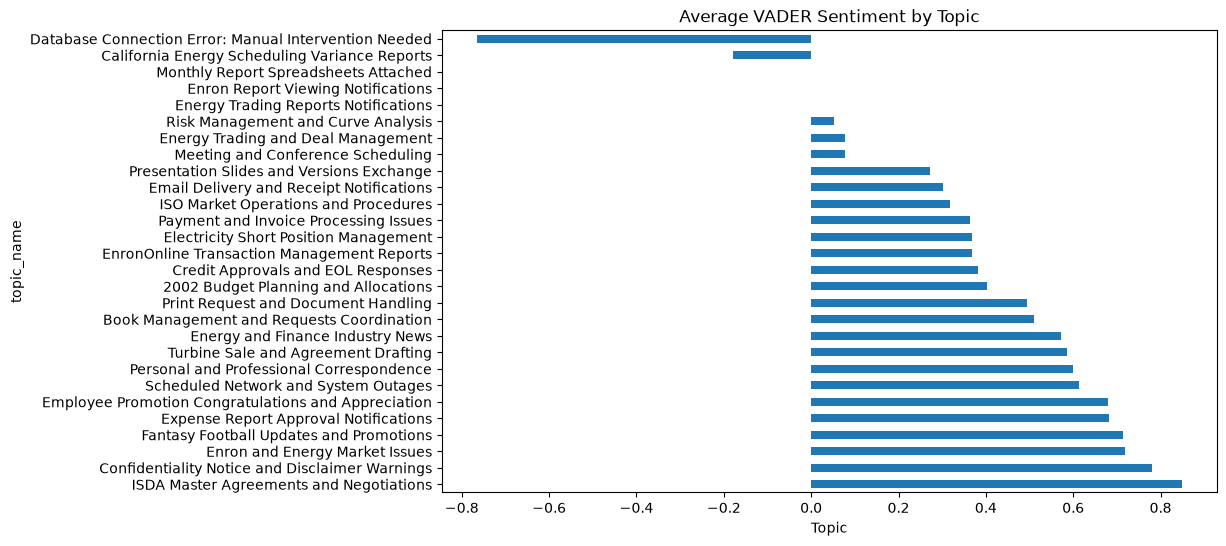

In [56]:
# bar chart of vader sentiment by topic using topic_name
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.groupby('topic_name')['vader'].median().sort_values(ascending=False).plot(kind='barh')
plt.title('Average VADER Sentiment by Topic')
plt.xlabel('Topic')

ISDA Master Agreements and Negotiations is probably very positive due to "agreements" being scattered throughout.
Since these are business emails, I'll choose not to really trust the sentiments by topic.

#### VADER over time

In [57]:
df["Date"] = pd.to_datetime(df["Date"])

In [58]:
# Keep dates inside the Tukey fences: Q1 - 1.5*IQR .. Q3 + 1.5*IQR
q1 = df["Date"].quantile(0.25)
q3 = df["Date"].quantile(0.75)
iqr = q3 - q1
df_date_iqr = df[df["Date"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]


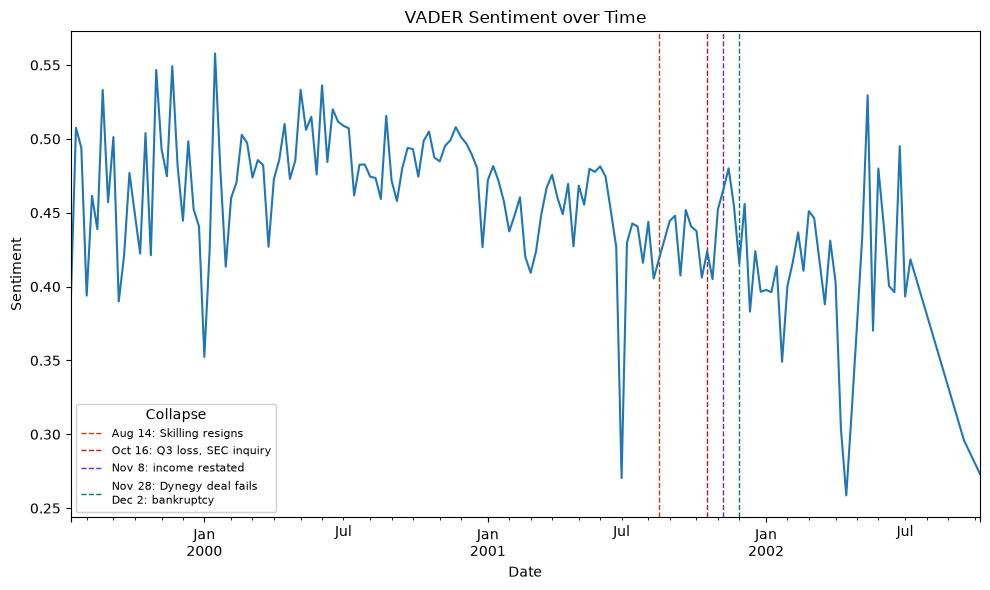

In [59]:
# plot vader over time median by week
plt.figure(figsize=(10, 6))
df_date_iqr.groupby(df_date_iqr['Date'].dt.to_period('W'))['vader'].mean().plot()
plt.title('VADER Sentiment over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment')
mark_collapse(loc="lower left")
plt.tight_layout()
plt.show()


We can see the vader sentiment go down over time. I'd do a transformer-based sentiment analysis but it'll take too long due to compute.

### Network Analysis

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144085 entries, 0 to 144084
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   thread_id    144085 non-null  int64              
 1   n_messages   144085 non-null  int64              
 2   embed_text   144085 non-null  str                
 3   ctfidf_text  144085 non-null  str                
 4   subj_norm    134948 non-null  str                
 5   date_parsed  144085 non-null  str                
 6   From         144085 non-null  str                
 7   To           138453 non-null  str                
 8   Subject      138661 non-null  str                
 9   Date         144084 non-null  datetime64[us, UTC]
 10  tokens       144085 non-null  str                
 11  tokens_ph    144085 non-null  str                
 12  vader        144085 non-null  float64            
 13  topic        144085 non-null  int64              
 14  topic_name   14

In [61]:
import networkx as nx
edges = (df.explode("To").dropna(subset=["To"])
        .query("To != '' and `From` != ''")
        .groupby(["From", "To"]).size().reset_index(name="w"))
G = nx.DiGraph(); G.add_weighted_edges_from(edges[["From", "To", "w"]].itertuples(index=False))
G = G.subgraph([n for n, d in G.degree() if d >= 3]).copy()

pr = nx.pagerank(G, weight="weight")
btw = nx.betweenness_centrality(G, k=min(500, len(G)), weight=None, seed=42)
UG = G.to_undirected()
comms = nx.community.louvain_communities(UG, weight="weight", seed=42)

node_comm = {n: i for i, c in enumerate(comms) for n in c}

cent = pd.DataFrame({"pagerank": pr, "betweenness":btw}).assign(community=pd.Series(node_comm))
print(cent.sort_values("pagerank", ascending=False).head(15))
print("modularity:", nx.community.modularity(UG, comms, weight="weight"))

                           pagerank  betweenness  community
louise.kitchen@enron.com   0.017572     0.038037        101
jeff.dasovich@enron.com    0.013135     0.060882        172
gerald.nemec@enron.com     0.010858     0.036688         88
tana.jones@enron.com       0.010628     0.043935        300
sally.beck@enron.com       0.010265     0.040847        101
sara.shackleton@enron.com  0.010201     0.038256        300
mark.taylor@enron.com      0.008994     0.027189        300
kay.mann@enron.com         0.007733     0.028806        317
steven.kean@enron.com      0.006382     0.023997        172
vince.kaminski@enron.com   0.006142     0.041283        137
chris.germany@enron.com    0.005996     0.032072         88
rod.hayslett@enron.com     0.005584     0.023349        126
michelle.cash@enron.com    0.005528     0.030813        193
john.lavorato@enron.com    0.005457     0.017040        101
richard.shapiro@enron.com  0.005266     0.005802        172
modularity: 0.6981792229481181


- **PageRank** measures who receives mail from important people
- **Betweenness** identifies brokers who connect otherwise separate groups. These people are often the key informants in an investigation or process review.
- **Louvain communities** approximate the real organizational units. 

In [62]:
# combine network and topics

# Senders below the degree cutoff are absent from node_comm; keep those as <NA>.
df["community"] = df["From"].map(node_comm).astype("Int64")

# Crosstab on topic id so the BERTopic outlier bin (-1) can be dropped.
# Its LLM label is a real-looking name, so filtering columns against -1
# only works while the columns are still ids.
ct = pd.crosstab(df["community"], df["topic"], normalize="index")
ct = ct.drop(columns=[-1], errors="ignore")
ct = ct.loc[ct.sum(axis=1) > 0]
ct = ct.div(ct.sum(axis=1), axis=0)

labels = df.drop_duplicates("topic").set_index("topic")["topic_name"]
ct = ct.rename(columns=labels)

display(ct.style.background_gradient(cmap="Blues"))
ct.idxmax(axis=1).rename("dominant_topic")


topic,Enron and Energy Market Issues,Personal and Professional Correspondence,Meeting and Conference Scheduling,ISDA Master Agreements and Negotiations,Risk Management and Curve Analysis,California Energy Scheduling Variance Reports,Turbine Sale and Agreement Drafting,Scheduled Network and System Outages,Fantasy Football Updates and Promotions,ISO Market Operations and Procedures,Energy Trading and Deal Management,Credit Approvals and EOL Responses,EnronOnline Transaction Management Reports,Employee Promotion Congratulations and Appreciation,Expense Report Approval Notifications,Email Delivery and Receipt Notifications,Book Management and Requests Coordination,Monthly Report Spreadsheets Attached,Electricity Short Position Management,Confidentiality Notice and Disclaimer Warnings,Presentation Slides and Versions Exchange,2002 Budget Planning and Allocations,Print Request and Document Handling,Enron Report Viewing Notifications,Energy Trading Reports Notifications,Payment and Invoice Processing Issues,Database Connection Error: Manual Intervention Needed
community,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.333333,0.333333,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,0.250000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


community
0                 Enron and Energy Market Issues
1      Presentation Slides and Versions Exchange
3                 Enron and Energy Market Issues
4       Personal and Professional Correspondence
5                 Enron and Energy Market Issues
                         ...                    
327            Meeting and Conference Scheduling
329               Enron and Energy Market Issues
330               Enron and Energy Market Issues
331     Email Delivery and Receipt Notifications
332            Meeting and Conference Scheduling
Name: dominant_topic, Length: 201, dtype: str

### Time Analysis

topic_name
California Energy Scheduling Variance Reports    0.131446
Meeting and Conference Scheduling                0.072212
Energy Trading and Deal Management               0.055369
Personal and Professional Correspondence         0.051634
Fantasy Football Updates and Promotions          0.050467
Enron and Energy Market Issues                   0.044511
ISO Market Operations and Procedures             0.041935
Name: largest 6-month rise in share, dtype: float64


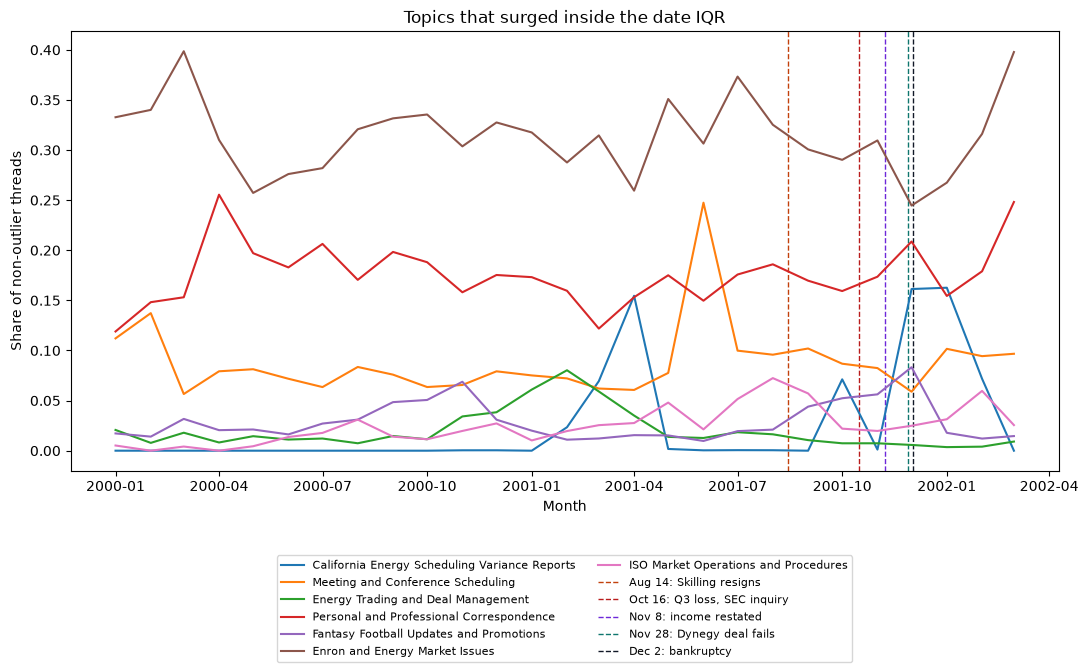

In [63]:
# Same Tukey fence as the sentiment plot: Q1 - 1.5*IQR .. Q3 + 1.5*IQR.
# Topic -1 is the outlier bin, so it stays out of the shares.
dates = pd.to_datetime(df["Date"], utc=True)
q1, q3 = dates.quantile(0.25), dates.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

window = df.loc[dates.between(lo, hi) & df["topic"].ne(-1)].copy()
window["month"] = dates.loc[window.index].dt.tz_localize(None).dt.to_period("M")
monthly = window.groupby(["month", "topic_name"]).size().unstack(fill_value=0)
# A month of a few dozen threads can look like a surge. Keep months with real volume.
monthly = monthly.loc[monthly.sum(axis=1) >= 500]
share = monthly.div(monthly.sum(axis=1), axis=0)

# Largest rise in a 3-month average share versus six months earlier.
roll = share.rolling(3, min_periods=3).mean()
rise = roll - roll.shift(6)
surge = rise.max().sort_values(ascending=False)
surged = surge[surge >= 0.03]
print(surged.rename("largest 6-month rise in share"))

plt.figure(figsize=(11, 7))
for name in surged.index:
    plt.plot(share.index.to_timestamp(), share[name], label=name)
mark_collapse(legend=False)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8)
plt.title("Topics that surged inside the date IQR")
plt.xlabel("Month")
plt.ylabel("Share of non-outlier threads")
plt.tight_layout()
plt.show()


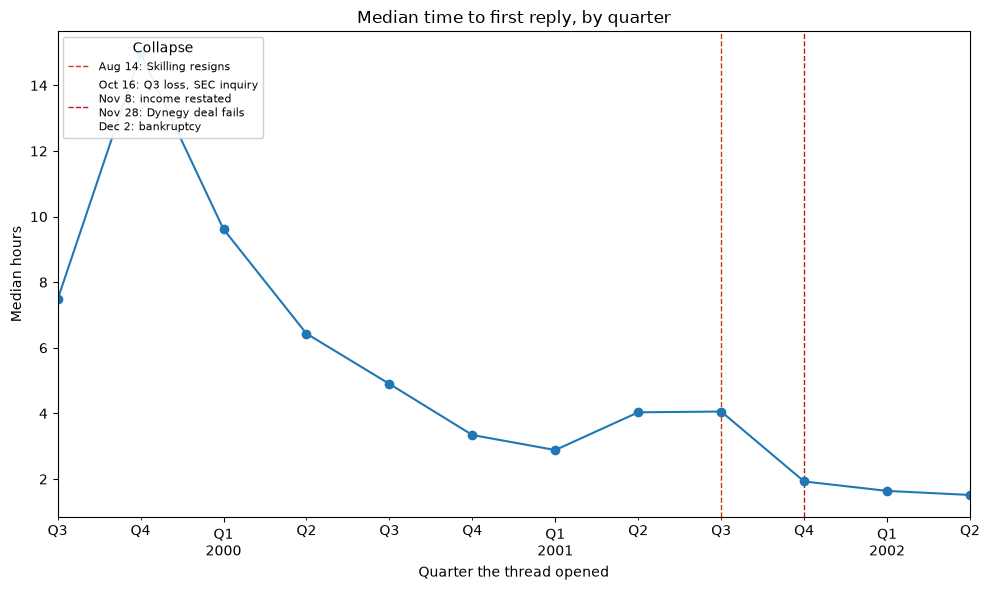

,n,median_hours
quarter,,
1999Q3,160,7.48
1999Q4,242,14.98
2000Q1,791,9.62
2000Q2,1269,6.43
2000Q3,1783,4.90
2000Q4,2760,3.34
2001Q1,2718,2.88
2001Q2,3245,4.03
2001Q3,2106,4.06


In [64]:
# Median hours from the first message in a thread to the second, by the quarter it opened.
# Same-timestamp pairs are mailbox copies, not replies, so only positive gaps count.
msg_dates = pd.read_csv(
    "emails_preprocessed_no_spam.csv",
    usecols=["thread_id", "date_parsed"],
)
msg_dates["date_parsed"] = pd.to_datetime(msg_dates["date_parsed"], utc=True, errors="coerce")
msg_dates = msg_dates.dropna(subset=["date_parsed"]).sort_values(["thread_id", "date_parsed"])
msg_dates["rank"] = msg_dates.groupby("thread_id").cumcount()
opened = msg_dates.loc[msg_dates["rank"] == 0].set_index("thread_id")["date_parsed"]
replied = msg_dates.loc[msg_dates["rank"] == 1].set_index("thread_id")["date_parsed"]
replies = pd.DataFrame({
    "opened": opened,
    "hours": (replied - opened).dt.total_seconds() / 3600,
}).dropna()
replies = replies[(replies["hours"] > 0) & replies["opened"].between(lo, hi)]
replies["quarter"] = replies["opened"].dt.tz_convert(None).dt.to_period("Q")
by_q = replies.groupby("quarter")["hours"].agg(n="size", median_hours="median")
by_q = by_q[by_q["n"] >= 30]

plt.figure(figsize=(10, 6))
by_q["median_hours"].plot(marker="o")
plt.title("Median time to first reply, by quarter")
plt.xlabel("Quarter the thread opened")
plt.ylabel("Median hours")
mark_collapse()
plt.tight_layout()
plt.show()
by_q.round(2)


### Classification Model

                                                       precision    recall  f1-score   support

                 2002 Budget Planning and Allocations      0.895     0.958     0.925        71
            Book Management and Requests Coordination      0.835     0.960     0.893       100
        California Energy Scheduling Variance Reports      1.000     0.993     0.996       421
       Confidentiality Notice and Disclaimer Warnings      0.646     0.948     0.768        77
                   Credit Approvals and EOL Responses      0.981     0.963     0.972       216
Database Connection Error: Manual Intervention Needed      1.000     0.976     0.988        41
                Electricity Short Position Management      0.884     0.938     0.910        81
             Email Delivery and Receipt Notifications      0.832     0.990     0.904       105
  Employee Promotion Congratulations and Appreciation      0.617     0.874     0.723       151
                 Energy Trading Reports Notificat

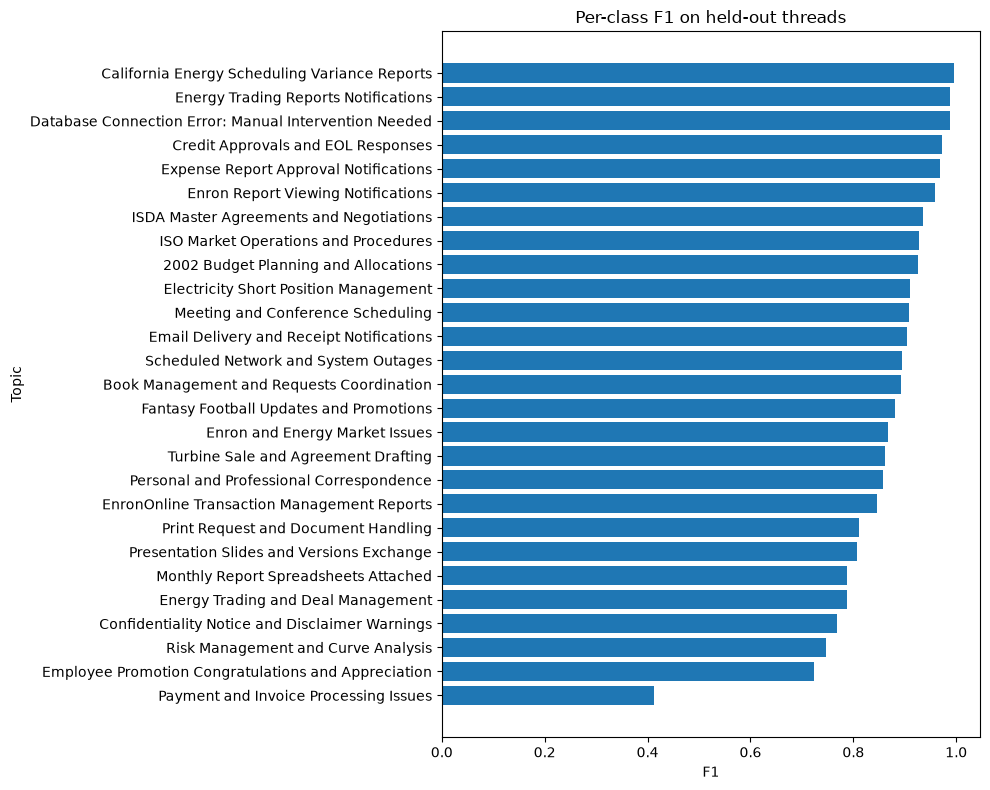

Payment and Invoice Processing Issues                  0.413
Employee Promotion Congratulations and Appreciation    0.723
Risk Management and Curve Analysis                     0.747
dtype: float64


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

# Topic -1 is BERTopic's outlier bin (~86k threads). The LLM name is not a real class.
labeled = df.loc[df["topic"] != -1, ["embed_text", "topic_name"]]
X_train, X_test, y_train, y_test = train_test_split(
    labeled["embed_text"],
    labeled["topic_name"],
    test_size=0.2,
    random_state=42,
    stratify=labeled["topic_name"],
)

vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.5,
    sublinear_tf=True,
    max_features=20_000,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Class sizes run from ~200 to ~17k, so weight the loss by class.
clf = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    max_iter=500,
    random_state=42,
)
clf.fit(X_train_tfidf, y_train)
y_pred = clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, digits=3))

f1 = pd.Series(
    f1_score(y_test, y_pred, average=None, labels=clf.classes_),
    index=clf.classes_,
).sort_values()
plt.figure(figsize=(10, 8))
plt.barh(f1.index, f1.values)
plt.title("Per-class F1 on held-out threads")
plt.xlabel("F1")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()
# Invoice processing is the weak class: few threads, and risk/curve mail
# shares the money vocabulary, so precision stays low. Promotions and risk
# analysis are next; both overlap personal correspondence.
print(f1.head(3).round(3))
